In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

In [14]:
# Load Data
data = pd.read_csv('../data/Student data.csv')

# Define columns based on project variables
columns = [
    'First_Term_GPA', 'Second_Term_GPA', 'First_Language', 'Funding', 
    'School', 'FastTrack', 'Coop', 'Residency', 'Gender', 
    'Prev_Education', 'Age_Group', 'HS_Average', 'Math_Score', 
    'English_Grade', 'FirstYearPersistence'
]
data.columns = columns

data.columns

Index(['First_Term_GPA', 'Second_Term_GPA', 'First_Language', 'Funding',
       'School', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Prev_Education',
       'Age_Group', 'HS_Average', 'Math_Score', 'English_Grade',
       'FirstYearPersistence'],
      dtype='object')

In [15]:
# 1. Missing Data Analysis
missing_summary = data.isnull().sum()
print("Missing Data Summary:")
print(missing_summary)

Missing Data Summary:
First_Term_GPA           6
Second_Term_GPA         23
First_Language          23
Funding                 23
School                  23
FastTrack               23
Coop                    23
Residency               23
Gender                  23
Prev_Education          23
Age_Group               23
HS_Average              23
Math_Score              23
English_Grade           23
FirstYearPersistence    23
dtype: int64


In [16]:
# Summary of the dataset
print("\nDataset summary:\n", data.describe())

# Check for duplicates
duplicates = data.duplicated().sum()
print("\nNumber of duplicate rows:", duplicates)


Dataset summary:
            Funding  School    FastTrack         Coop    Residency  \
count  1437.000000  1437.0  1437.000000  1437.000000  1437.000000   
mean      2.926931     6.0     1.741823     1.695198     1.406402   
std       1.257658     0.0     0.437784     0.460484     0.491332   
min       1.000000     6.0     1.000000     1.000000     1.000000   
25%       2.000000     6.0     1.000000     1.000000     1.000000   
50%       2.000000     6.0     2.000000     2.000000     1.000000   
75%       4.000000     6.0     2.000000     2.000000     2.000000   
max       9.000000     6.0     2.000000     2.000000     2.000000   

            Gender  FirstYearPersistence  
count  1437.000000           1437.000000  
mean      1.774530              0.791928  
std       0.419699              0.406070  
min       1.000000              0.000000  
25%       2.000000              1.000000  
50%       2.000000              1.000000  
75%       2.000000              1.000000  
max       3.000

In [17]:
# ***************************
# Missing Values Strategy.
# Method A: Dropping all NaNs 
df_dropped = data.replace('?', np.nan).dropna()

# Method B: Imputation (Mean for Numerical, Mode for Categorical)
df_imputed = data.copy()

# Convert numerical columns from strings to numbers, turning '?' into NaN
num_features = ['HS_Average', 'Math_Score', 'First_Term_GPA', 'Second_Term_GPA']
for col in num_features:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce')

# Fill numerical gaps with the Mean 
df_imputed[num_features] = df_imputed[num_features].fillna(df_imputed[num_features].mean())

# Fill Categorical gaps with the Mode (Most Frequent)
cat_features = ['First_Language', 'Gender', 'School', 'Funding', 'English_Grade']
for col in cat_features:
    # Handle '?' in categorical columns before finding mode
    df_imputed[col] = df_imputed[col].replace('?', np.nan)
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

# Final safety drop only for the Target labels if they remain null 
df_imputed = df_imputed.dropna(subset=['FirstYearPersistence', 'Second_Term_GPA'])


In [27]:
# ***************************
# Persistence Experiment (Classification)
# ***************************

def run_persistence_experiment(df, name):
    
    # Feature And Target Separation
    X = df.drop(['FirstYearPersistence', 'Second_Term_GPA'], axis=1)
    y = df['FirstYearPersistence'].astype(int)
    
    # Scale only numeric columns for better Neural Network convergence
    scaler = StandardScaler()
    numeric_df = X.select_dtypes(include=[np.number])
    X_scaled = scaler.fit_transform(numeric_df)
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    
    # Model architecture for Binary Classification 
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.5)) # to prevent overfitting
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # for binary classification
    model.summary()     

    # Model complilation and training
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=10, validation_data=(X_test, y_test), verbose=0)
    
    print ("*" * 50)
    max_acc = max(history.history['val_accuracy'])
    print(f"Persistence Model ({name}) - Max Val Accuracy: {max_acc:.4f}")
    
    return model, history

# Train both versions to compare performance
model_drop, hist_drop = run_persistence_experiment(df_dropped, "Dropped")
model_imp, hist_imp = run_persistence_experiment(df_imputed, "Imputed")

/opt/anaconda3/envs/sklearn-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

**************************************************
Persistence Model (Imputed) - Max Val Accuracy: 0.8611


In [28]:
# ***************************
# Academic Performance Model (Regression)
# ***************************
academic_features = ['HS_Average', 'Math_Score', 'English_Grade', 'First_Term_GPA']

X_acad = df_imputed[academic_features]
y_acad = df_imputed['Second_Term_GPA']

scaler_acad = StandardScaler()
X_acad_scaled = scaler_acad.fit_transform(X_acad)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_acad_scaled, y_acad, test_size=0.2, random_state=42)

model_academic = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_a.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Continuous value output
])

model_academic.summary()

# Model compilation and training for regression
model_academic.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_academic.fit(X_train_a, y_train_a, epochs=50, batch_size=10, validation_data=(X_test_a, y_test_a), verbose=1)

model_academic_accuracy = model_academic.evaluate(X_test_a, y_test_a, verbose=0)
print("\n")
print(f"Academic Performance Model - Test MAE: {model_academic_accuracy[1]:.4f}")

/opt/anaconda3/envs/sklearn-env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0401 - mae: 1.4315 - val_loss: 0.7999 - val_mae: 0.7233
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 0.7933 - mae: 0.6909 - val_loss: 0.5636 - val_mae: 0.5819
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 0.6607 - mae: 0.6188 - val_loss: 0.5196 - val_mae: 0.5654
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - loss: 0.6134 - mae: 0.5878 - val_loss: 0.4752 - val_mae: 0.5083
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.5931 - mae: 0.5722 - val_loss: 0.4790 - val_mae: 0.5249
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - loss: 0.5752 - mae: 0.5660 - val_loss: 0.4762 - val_mae: 0.5261
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.5668 - mae: 0.5598 - val_loss: 0.5285 - val_mae: 0.5438
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 0.5667 - mae: 0.5636 - val_loss: 0.4844 - val_mae: 0.5049
Epoch 9/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s

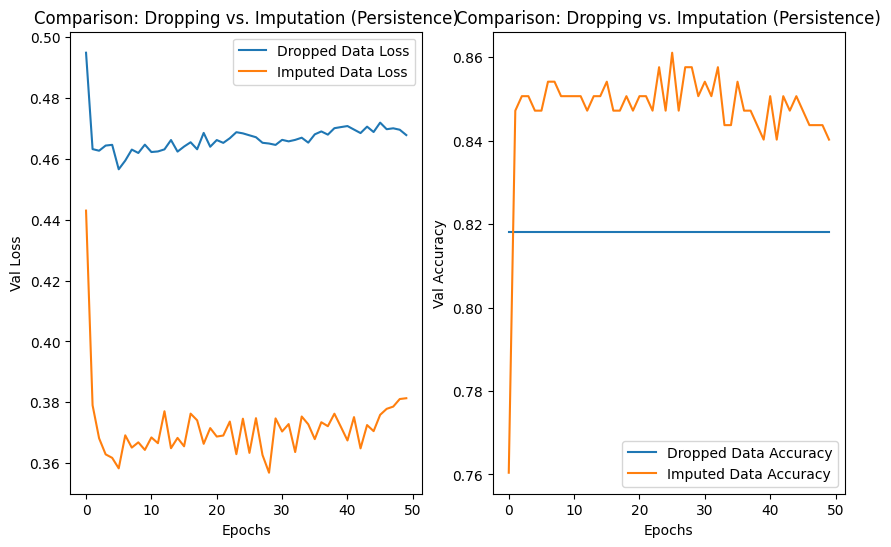

All tasks complete. Ready for full-stack integration!


In [29]:
# Visualizing the Comparison 
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(hist_drop.history['val_loss'], label='Dropped Data Loss')
plt.plot(hist_imp.history['val_loss'], label='Imputed Data Loss')
plt.title('Comparison: Dropping vs. Imputation (Persistence)')
plt.xlabel('Epochs')
plt.ylabel('Val Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_drop.history['val_accuracy'], label='Dropped Data Accuracy')
plt.plot(hist_imp.history['val_accuracy'], label='Imputed Data Accuracy')
plt.title('Comparison: Dropping vs. Imputation (Persistence)')
plt.xlabel('Epochs')
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()


# 6. Save Final Outputs
model_imp.save('../output/new_persistence_model.h5')
model_academic.save('../output/new_academic_model.h5')

joblib.dump(scaler_acad, '../output/new_scalar_academic.pkl')

print("All tasks complete. Ready for full-stack integration!")